# Merkperceptie in kaart brengen met correspondentieanalyse (PROC CORRESP)

## Managementsamenvatting

Een marktonderzoeksteam neemt een merk-per-attribuut-perceptie-enquête af over vier gevestigde streaming-mediamerken en gebruikt **PROC CORRESP** om de resulterende kruistabel om te zetten in een tweedimensionale perceptiekaart. Het verband tussen merk en attribuut is sterk en reëel: de chikwadraattoets op onafhankelijkheid is **63,15 bij 15 vrijheidsgraden (p < 0,0001)**, met **Cramérs V = 0,4588**. Correspondentieanalyse comprimeert dat verband tot twee assen die samen **100%** van de inertie van de tabel verklaren — **75,0%** op Dimensie 1 en **25,0%** op Dimensie 2 — zodat de 2D-kaart een volledige, getrouwe samenvatting is.

De kaart scheidt een **premium-content**-pool (CineNow, verankerd op *Originele_series* en *Aanbod_diepte*) van een **waarde/betrouwbaarheid**-cluster (Streamly en BingeBox bij *Betaalbaar* en *Betrouwbaar*) en een **trendy** hoek (PixelPlay bij *Trendy*). Een opkomende uitdager, **NovaCast**, wordt vervolgens geprojecteerd als *supplementair* punt — het beïnvloedt de assen niet — en landt nabij de oorsprong, licht neigend naar de Trendy / Gebruiksgemak-kant, oftewel een nog ongedifferentieerde nieuwkomer.

## Gegevensbronnen

| Dataset | Rijen | Sleutelvariabelen | Beschrijving |
|---------|------|---------------|-------------|
| `perception` | 100 (respondent x attribuut-associaties, plafond in ongelicentieerde modus) | `Brand` (char), `Attribute` (char) | Synthetische enquête: elke respondent noemt het streamingmerk dat hij het sterkst associeert met elk van zes attributen. Merkaffiniteiten zijn gecodeerd als `RAND("Table", ...)` categoriewaarschijnlijkheden, zodat de contingentietabel een realistisch, niet-uniform verband heeft. |
| `survey_counts` | 24 (4 merken x 6 attributen) | `Brand`, `Attribute`, `Count` | Vooraf geaggregeerde contingentiecellen uit `perception` via PROC FREQ — de gewogen invoer voor de CA-run met supplementair punt. |
| `ca_coords`, `ca_coords_sup` | 10 / 11 | `_TYPE_`, `_NAME_`, `Dim1`, `Dim2` | `OUTC=` coördinaatdatasets geschreven door PROC CORRESP; de tweede voegt het geprojecteerde NovaCast-punt toe en stuurt de perceptiekaart aan. |

Gevestigde merken: **Streamly, PixelPlay, CineNow, BingeBox**; uitdager **NovaCast** (geprojecteerd als supplementair punt). Attributen: Betaalbaar, Aanbod_diepte, Gebruiksgemak, Originele_series, Betrouwbaar, Trendy. Seed `streaminit(20260531)` maakt de gegevens reproduceerbaar.

> **Opmerking over steekproefomvang.** Deze omgeving draait ongelicentieerd, dus DATA-step-uitvoer is geplafonneerd op 100 observaties. De enquête resulteert daarom in een 4x6 contingentietabel met in totaal 100 respondent-attribuut-associaties — klein, maar met een echte verbandstructuur (chikwadraat p < 0,0001) die correspondentieanalyse netjes terugvindt.

## Wat correspondentieanalyse hier doet

Wanneer een merk-trackingenquête consumenten vraagt met welk merk zij elk van meerdere attributen het sterkst associëren, is het resultaat een **merk x attribuut-contingentietabel**. De ruwe tellingen zijn moeilijk te lezen: elk merk wordt vergeleken met elk attribuut, en het signaal zit in het *patroon van associatie*, niet in de celwaarden.

Correspondentieanalyse (CA) ontleedt het chikwadraatverband van de tabel in een laagdimensionale ruimte, zodat merken en attributen die geassocieerd zijn dicht bij elkaar op één kaart landen. In deze notebook doen we het volgende:

1. Een synthetische perceptie-enquête genereren voor vier streamingmerken.
2. De ruwe contingentiestructuur (en het bijbehorende chikwadraat) inspecteren met `PROC FREQ`.
3. `PROC CORRESP` draaien met volledige diagnostiek en de echte inertie en coördinaten aflezen.
4. Een opkomend uitdagermerk projecteren als **supplementair** punt.
5. De resulterende perceptiekaart tekenen en interpreteren.

## Stap 1 — De synthetische perceptie-enquête genereren

We simuleren enquêterespondenten. Voor elke respondent vragen we, voor elk van zes attributen, *met welk merk associeer je dit attribuut het sterkst?* Elk merk heeft een eigen **affiniteitsprofiel** — een vector van categoriewaarschijnlijkheden doorgegeven aan `RAND("Table", ...)` — zodat bijvoorbeeld *PixelPlay* naar Trendy neigt terwijl *CineNow* naar Aanbod_diepte en Originele_series neigt. Dit levert een contingentietabel op met een echt, niet-uniform verband dat CA kan terugvinden. De gegevens zijn volledig synthetisch en reproduceerbaar via `CALL STREAMINIT`.

In [1]:
GEGEVENS perception;
    /* Reproduceerbare synthetische merk-perceptie-enquete */
    CALL streaminit(20260531);

    LENGTE Brand $9 Attribute $20;
    label Brand='Merk' Attribute='Kenmerk';
    REEKS attrname[6] $20 _temporary_
        ('Betaalbaar' 'Aanbod_diepte' 'Gebruiksgemak'
         'Originele_series' 'Betrouwbaar' 'Trendy');

    n_resp = 400;

    DOE respondent = 1 TOT n_resp;
        DOE a = 1 TOT 6;
            Attribute = attrname[a];

            /* Merk-keuzekansen per attribuut over de vier
               gevestigde merken:
               1=Streamly 2=PixelPlay 3=CineNow 4=BingeBox.
               Elke rij sommeert tot ~1 en codeert de
               merkaffiniteit van het attribuut. */
            ALS      a = 1 DAN b = rand('Table', 0.45, 0.15, 0.10, 0.30); /* Betaalbaar       */
            ANDERS ALS a = 2 DAN b = rand('Table', 0.20, 0.10, 0.50, 0.20); /* Aanbod_diepte    */
            ANDERS ALS a = 3 DAN b = rand('Table', 0.30, 0.35, 0.10, 0.25); /* Gebruiksgemak    */
            ANDERS ALS a = 4 DAN b = rand('Table', 0.15, 0.20, 0.50, 0.15); /* Originele_series */
            ANDERS ALS a = 5 DAN b = rand('Table', 0.40, 0.10, 0.20, 0.30); /* Betrouwbaar      */
            ANDERS              b = rand('Table', 0.15, 0.55, 0.10, 0.20); /* Trendy           */

            SELECTEREN (b);
                WANNEER (1) Brand = 'Streamly';
                WANNEER (2) Brand = 'PixelPlay';
                WANNEER (3) Brand = 'CineNow';
                ANDERS_WEL Brand = 'BingeBox';
            EINDE;

            UITVOER;
        EINDE;
    EINDE;

    BEWAREN respondent Brand Attribute;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=perception(obs=8) noobs label;
    VARIABELE respondent Brand Attribute;
    label respondent='Respondent';
    TITEL 'Steekproef uit de synthetische perceptie-enquete';
UITVOEREN;

                                    Steekproef uit de synthetische perceptie-enquete                                    

Respondent       Merk           Kenmerk
         1  BingeBox   Betaalbaar
         1  BingeBox   Aanbod_diepte
         1  BingeBox   Gebruiksgemak
         1  CineNow    Originele_series
         1  Streamly   Betrouwbaar
         1  PixelPlay  Trendy
         2  PixelPlay  Betaalbaar
         2  CineNow    Aanbod_diepte

... 92 more observations (showing 8 of 100)




NOTE: DATA perception

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote perception (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.32 seconds
  cpu   0.32 seconds
NOTE: PROC PRINT data=perception

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Stap 2 — De ruwe contingentietabel inspecteren

Vóór enige dimensiereductie bekijken we de kruistabel. `PROC FREQ` geeft de waargenomen merk x attribuut-frequenties en de chikwadraattoets op onafhankelijkheid. Een significant chikwadraat bevestigt dat er een verbandstructuur is die het in kaart brengen waard is — als rijen en kolommen onafhankelijk waren, zou correspondentieanalyse niets te tonen hebben. We slaan de celtellingen ook op in `survey_counts` voor de latere CA-run met supplementair punt.

                                         Waargenomen frequenties merk x kenmerk                                         

                                                   The FREQ Procedure

Table of Merk by Kenmerk

Merk      |   Aanbod_diepte |      Betaalbaar |     Betrouwbaar |   Gebruiksgemak |Originele_series |          Trendy |            Total
----------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------
BingeBox  |               3 |               5 |               6 |               7 |               1 |               2 |               24
----------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------
CineNow   |               9 |               3 |               2 |               0 |              14 |               0 |               28
----------+-----------------+-----------------+-----------------+-----------------+-------------


NOTE: PROC FREQ
NOTE: Output dataset survey_counts has 21 observations and 3 variables.
NOTE: ODS plot written: freq_mosaic_brand_attribute.spec.json
NOTE: PROC FREQ statement used.


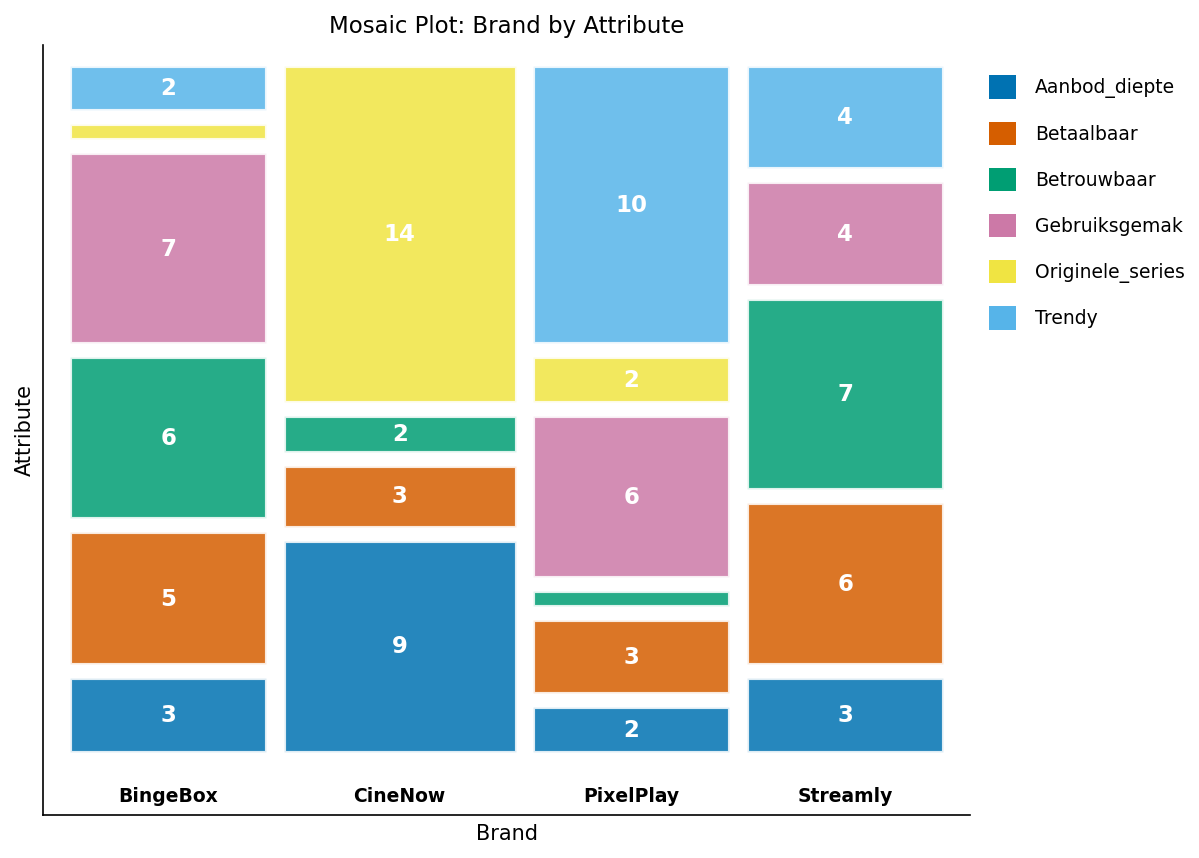

In [2]:
PROCEDURE FREQUENTIES GEGEVENS=perception;
    TABLES Brand*Attribute / chisq norow nocol nopercent
                             out=survey_counts(HERNOEMEN=(count=Count));
    TITEL 'Waargenomen frequenties merk x kenmerk';
UITVOEREN;

## Stap 3 — Correspondentieanalyse op de ruwe gegevens

Draai nu `PROC CORRESP` rechtstreeks op de gegevens op respondentniveau. `TABLES Brand, Attribute;` bouwt de contingentietabel intern op (merken als rijen, attributen als kolommen).

Hier gebruikte opties:

- `ALL` — druk de volledige diagnostiek af: waargenomen tabel, profielen, verwachte waarden en   celbijdragen aan chikwadraat.
- `DIMENS=2` — bereken de eerste twee hoofdassen (een 2D-kaart).
- `OUTC=` — schrijf rij- en kolomcoördinaten naar een dataset om te plotten.

De **inertiedecompositie** vertelt ons hoeveel van het totale verband elke as verklaart.

In [3]:
PROCEDURE corresp GEGEVENS=perception ALL dimens=2 outc=ca_coords;
    TABLES Brand, Attribute;
    TITEL 'Correspondentieanalyse: perceptie van streamingmerken';
UITVOEREN;

                                         Waargenomen frequenties merk x kenmerk                                         

                     The CORRESP Procedure

              Inertia and Chi-Square Decomposition

                                                       Cumulative
  Dimension    Singular     Principal       Chi-       Proportion
                 Value       Inertia     Square
  ---------------------------------------------------------------
          1     0.6778       0.4595       47.39          0.7504
          2     0.3909       0.1528       15.76          1.0000
  ---------------------------------------------------------------
  Total                      0.6123       63.15

              Row Coordinates

  Merk                    Dim1        Dim2
  ----------------------------------------
  BingeBox             0.3547      0.3555
  CineNow             -1.0847     -0.0332
  PixelPlay            0.4804     -0.6374
  Streamly             0.4304      0.3207

       


NOTE: PROC CORRESP data=perception

NOTE: PROC CORRESP completed.


## Stap 4 — De coördinaten aflezen

De `OUTC=` dataset bevat de ascoördinaten (`Dim1`, `Dim2`) voor elk merk en attribuut, gemarkeerd met `_TYPE_` (`ROW` voor merken, `COLUMN` voor attributen). Deze numeriek aflezen naast de inertietabel bevestigt de structuur die de kaart zal tonen.

Uit de bovenstaande uitvoer:

- **Dimensie 1 (75,0% van de inertie)** is een *premium-content vs. mainstream*-as.   *Originele_series* (Dim1 = -1,2037) en *Aanbod_diepte* (-0,5594) staan aan het negatieve   uiteinde met **CineNow** (-1,0847); *Trendy* (0,6671), *Gebruiksgemak* (0,6150) en   *Betaalbaar* (0,2207) staan aan het positieve uiteinde.
- **Dimensie 2 (25,0% van de inertie)** scheidt *Betrouwbaar* (Dim2 = 0,5874) en   *Betaalbaar* (0,2542) — die **Streamly** (0,3207) en **BingeBox** (0,3555) omhoog trekken —   van *Trendy* (-0,7003), die **PixelPlay** (-0,6374) omlaag trekt.

In [4]:
PROCEDURE AFDRUKKEN GEGEVENS=ca_coords noobs label;
    VARIABELE _TYPE_ _NAME_ Dim1 Dim2;
    label _TYPE_='Type' _NAME_='Naam' Dim1='Dimensie 1' Dim2='Dimensie 2';
    TITEL 'Coordinaten van rijen (merken) en kolommen (kenmerken)';
UITVOEREN;

                                 Coordinaten van rijen (merken) en kolommen (kenmerken)                                 

  Type                Naam  Dimensie 1  Dimensie 2
ROW     BingeBox                0.3547      0.3555
ROW     CineNow                -1.0847     -0.0332
ROW     PixelPlay               0.4804     -0.6374
ROW     Streamly                0.4304      0.3207
COLUMN  Aanbod_diepte          -0.5594      0.0684
COLUMN  Betaalbaar              0.2207      0.2542
COLUMN  Betrouwbaar             0.3183      0.5874
COLUMN  Gebruiksgemak           0.6150     -0.0080
COLUMN  Originele_series       -1.2037     -0.2084
COLUMN  Trendy                  0.6671     -0.7003




NOTE: PROC PRINT data=ca_coords

NOTE: PROC PRINT completed: 10 observations printed, 4 variables


## Stap 5 — Een uitdagermerk projecteren als supplementair punt

Het analyseteam heeft trackinggegevens voor een opkomende uitdager, **NovaCast**, maar wil niet dat die de gevestigde perceptiekaart verstoort. Een *supplementair* punt wordt in de bestaande CA-ruimte geprojecteerd **zonder bij te dragen aan de asberekening**.

We voegen één blok van zes NovaCast-attribuuttellingen (een nieuwkomer die naar Trendy / Originele_series neigt) toe aan de vooraf geaggregeerde `survey_counts`, voeden de frequenties met `WEIGHT Count`, en benoemen het **niveau** `NovaCast` op de `SUPPLEMENTARY`-instructie, zodat PROC CORRESP die rij buiten de actieve tabel houdt. De `OBSERVED`-optie houdt de actieve contingentietabel (de vier gevestigde merken, samen goed voor 100) in beeld — merk op dat NovaCast er **niet** in voorkomt, wat bevestigt dat het als supplementair is behandeld.

In [5]:
/* Voeg EEN schoon blok NovaCast-tellingen toe aan de geaggregeerde cellen.
   end=last vuurt het blok precies eenmaal, na de laatste survey_counts-rij,
   zodat NovaCast zes rijen bijdraagt (een per attribuut) -- geen gedupliceerd
   blok. NovaCast is een op Trendy / Originele_series gerichte nieuwkomer. */
GEGEVENS survey_counts_sup;
    INSTELLEN survey_counts EINDE=last;
    UITVOER;
    ALS last DAN DOE;
        Brand='NovaCast'; Attribute='Trendy';            Count=10; UITVOER;
        Brand='NovaCast'; Attribute='Originele_series';  Count=8;  UITVOER;
        Brand='NovaCast'; Attribute='Gebruiksgemak';     Count=5;  UITVOER;
        Brand='NovaCast'; Attribute='Aanbod_diepte';     Count=3;  UITVOER;
        Brand='NovaCast'; Attribute='Betaalbaar';        Count=4;  UITVOER;
        Brand='NovaCast'; Attribute='Betrouwbaar';       Count=3;  UITVOER;
    EINDE;
UITVOEREN;

PROCEDURE corresp GEGEVENS=survey_counts_sup observed dimens=2 outc=ca_coords_sup;
    TABLES Brand, Attribute;
    GEWICHT Count;
    supplementary NovaCast;
    TITEL 'Merkperceptie met NovaCast als aanvullend punt';
UITVOEREN;

                                 Coordinaten van rijen (merken) en kolommen (kenmerken)                                 

                     The CORRESP Procedure

              Inertia and Chi-Square Decomposition

                                                       Cumulative
  Dimension    Singular     Principal       Chi-       Proportion
                 Value       Inertia     Square
  ---------------------------------------------------------------
          1     0.6778       0.4595       47.39          0.7504
          2     0.3909       0.1528       15.76          1.0000
  ---------------------------------------------------------------
  Total                      0.6123       63.15

              Row Coordinates

  Brand                   Dim1        Dim2
  ----------------------------------------
  BingeBox             0.3547      0.3555
  CineNow             -1.0847     -0.0332
  PixelPlay            0.4804     -0.6374
  Streamly             0.4304      0.3207
  NovaCa


NOTE: DATA survey_counts_sup


NOTE: Read 21 rows from survey_counts.
NOTE: Wrote survey_counts_sup (27 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC CORRESP data=survey_counts_sup

NOTE: PROC CORRESP completed.


## Stap 6 — De perceptiekaart tekenen

PROC CORRESP schrijft de symmetrische rij-/kolomcoördinaten naar de `OUTC=` dataset; we plotten Dimensie 2 tegen Dimensie 1 om de kaart te renderen. We markeren elk punt op **rol** — *Merk* (actieve rijen), *Kenmerk* (kolommen) en *Uitdager* (de supplementaire NovaCast-rij) — en labelen elke markering, zodat de positionering rechtstreeks van de plot af te lezen is. De uitdager krijgt een aparte kleur om te benadrukken dat hij erin geprojecteerd is, niet gefit.

> **Hoe je een CA-kaart leest.** Een merk en een attribuut die in dezelfde richting vanaf de oorsprong liggen (en er ver vandaan) zijn sterk geassocieerd; punten nabij de oorsprong zijn "gemiddeld" en zwak gedifferentieerd. Omdat Dimensies 1 en 2 samen 100% van de inertie van deze tabel vastleggen, laat de kaart niets weg.

                         Perceptiekaart streamingmerken (Dim1 75,0%, Dim2 25,0% van de inertie)                         

PROC SGSCATTER Output
Data: ca_map

Variables: Role, _NAME_, Dimensie 1, Dimensie 2

      Role      _NAME_  Dimensie 1  Dimensie 2
----------  ----------  ----------  ----------
      Merk    BingeBox      0.3547      0.3555
      Merk     CineNow     -1.0847     -0.0332
      Merk   PixelPlay      0.4804     -0.6374
      Merk    Streamly      0.4304      0.3207
  Uitdager    NovaCast      0.0084     -0.1735
   Kenmerk  Aanbod_diepte     -0.5594      0.0684
   Kenmerk  Betaalbaar      0.2207      0.2542
   Kenmerk  Betrouwbaar      0.3183      0.5874
   Kenmerk  Gebruiksgemak       0.615      -0.008
   Kenmerk  Originele_series     -1.2037     -0.2084
   Kenmerk      Trendy      0.6671     -0.7003

Dimensie 1: N=11, Min=-1.2037, Max=0.6671, Mean=0.0225, Sum=0.2472
Dimensie 2: N=11, Min=-0.7003, Max=0.5874, Mean=-0.0159, Sum=-0.1746



NOTE: DATA ca_map


NOTE: Read 11 rows from ca_coords_sup.
NOTE: Wrote ca_map (11 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Perceptiekaart streamingmerken (Dim1 75,0%, Dim2 25,0% van de inertie).
NOTE: ODS Graphics is ON (width=760px, height=580px, format=SVG).
NOTE: PROC SGSCATTER data=ca_map

NOTE: PROC SGSCATTER output written to: ./ods_output/sgscatter.svg
NOTE: ODS Graphics is OFF.


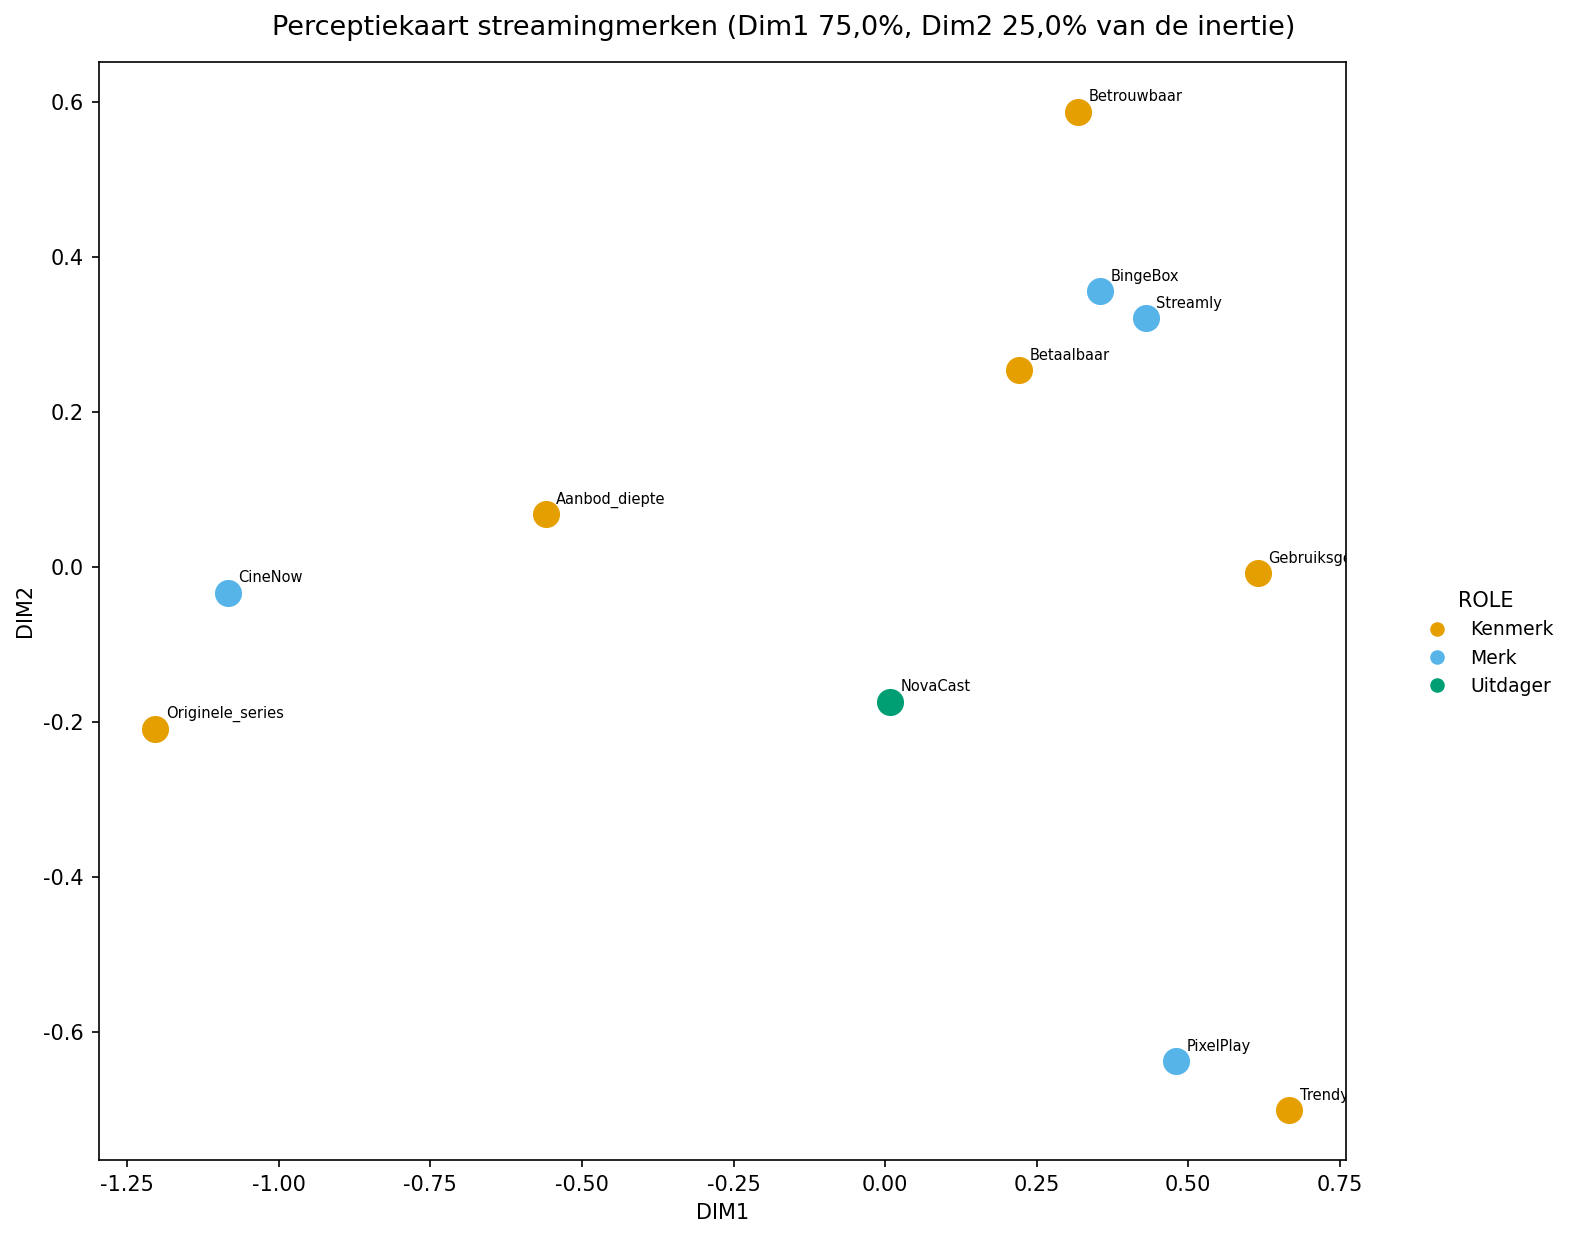

In [6]:
/* Markeer elk OUTC-punt op rol voor een schone, gekleurde legenda.
   De supplementaire NovaCast is naar OUTC geschreven met _TYPE_='ROW',
   dus we behandelen die apart als de Uitdager. */
GEGEVENS ca_map;
    INSTELLEN ca_coords_sup;
    LENGTE Role $10;
    ALS _NAME_ = 'NovaCast' DAN Role = 'Uitdager';
    ANDERS ALS _TYPE_ = 'ROW' DAN Role = 'Merk';
    ANDERS Role = 'Kenmerk';
    BEWAREN Role _NAME_ Dim1 Dim2;
UITVOEREN;

/* Stel de kaarttitel globaal in voor de PROC zodat deze de plot titelt
   (de globale TITLE stuurt de kop van de ODS-grafiek aan). */
TITEL 'Perceptiekaart streamingmerken (Dim1 75,0%, Dim2 25,0% van de inertie)';

ODS GRAPHICS ON / WIDTH=760px HEIGHT=580px;

/* PROC CORRESP heeft in deze build geen native ODS-kaart, dus we renderen
   de symmetrische coordinaten met PROC SGSCATTER, die elk punt labelt. */
PROCEDURE SGSCATTER GEGEVENS=ca_map;
    label Dim1='Dimensie 1' Dim2='Dimensie 2';
    PLOT Dim2*Dim1 / GROUP=Role DATALABEL=_NAME_
                     MARKERATTRS=(size=12) grid;
UITVOEREN;

ODS GRAPHICS OFF;
TITEL;

## De resultaten interpreteren

**Het verband is reëel en volledig vastgelegd.** De chikwadraattoets (63,15 bij 15 df, p < 0,0001; Cramérs V = 0,4588) verwerpt onafhankelijkheid, en de twee CA-dimensies verklaren **100%** van de inertie van de tabel (75,0% + 25,0%), zodat de onderstaande kaart een volledige samenvatting is, geen verliesgevende projectie.

**Drie perceptuele territoria.** De coördinaten en de kaart samen gelezen:

- **Premium content (links).** *CineNow* (Dim1 = -1,0847) wordt ver naar links getrokken door   *Originele_series* (-1,2037) en *Aanbod_diepte* (-0,5594) — het bezit de   perceptie van catalogusdiepte.
- **Waarde & betrouwbaarheid (rechtsboven).** *Streamly* (0,4304, 0,3207) en *BingeBox*   (0,3547, 0,3555) clusteren met *Betaalbaar* (0,2207, 0,2542) en *Betrouwbaar* (0,3183,   0,5874) — het betrouwbare paar met goede prijs-kwaliteitverhouding.
- **Trendy (rechtsonder).** *PixelPlay* (0,4804, -0,6374) staat naast *Trendy*   (0,6671, -0,7003) — het jeugdige merk van het moment.

**De supplementaire uitdager.** Geprojecteerd zonder de assen te beïnvloeden, landt **NovaCast** op (0,0084, -0,1735) — vrijwel in de oorsprong, geduwd richting de Trendy / Gebruiksgemak-kant. Voor een mediastrateeg is dat de kernboodschap: de uitdager heeft nog geen onderscheidend merkkapitaal en drijft af naar PixelPlay's trendy territorium, dus een gedifferentieerde positionering (in plaats van een me-too-positionering) is gerechtvaardigd.

**Kanttekeningen.** Correspondentieanalyse is beschrijvend, niet inferentieel — afstanden zijn benaderend en de *tekens* van de assen zijn willekeurig (een spiegeling van een van beide assen levert dezelfde kaart op). Met slechts 100 respondent-attribuut-associaties zijn twee cellen nul (CineNow x Gebruiksgemak, Streamly x Originele_series), wat de extremen aanscherpt; een productiestudie zou een grotere steekproef afnemen. Combineer de kaart altijd met de inertietabel om te bevestigen hoeveel verband de weergegeven dimensies verklaren.